# Vanilla pricing

## Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.market.market_data import MarketData
from src.models.black_scholes import BlackScholesModel
from src.models.discounting_model import DiscountingModel
from src.products.vanilla_option import VanillaOption
from src.products.zero_coupon_bond import ZeroCouponBond

## ZC pricing

In [4]:
zc = ZeroCouponBond(
    product_id="ZC-2Y",
    notional=100.0,
    maturity=2.0,
)

discount_model = DiscountingModel(rate=0.03)

zc_price = discount_model.price(zc)
zc_risk = discount_model.risk(zc)

zc_price, zc_risk

(94.17645335842487,
 {'price': 94.17645335842487, 'duration': 2.0, 'dv01': 0.018835290671684973})

## Call/ Put pricing with Black-Scholes

In [5]:
market_data = MarketData(
    spot=100.0,
    rate=0.05,
    volatility=0.20,
    dividend_yield=0.0,
)

call = VanillaOption(
    product_id="CALL-ATM",
    option_type="call",
    strike=100.0,
    maturity=1.0,
)

put = VanillaOption(
    product_id="PUT-ATM",
    option_type="put",
    strike=100.0,
    maturity=1.0,
)

bs_model = BlackScholesModel()

call_result = bs_model.price_and_greeks(call, market_data)
put_result = bs_model.price_and_greeks(put, market_data)

call_result, put_result

(BlackScholesResult(price=10.450583572185565, delta=0.6368306511756191, gamma=0.018762017345846895, vega=37.52403469169379, theta=-6.414027546438197, rho=53.232481545376345),
 BlackScholesResult(price=5.573526022256971, delta=-0.3631693488243809, gamma=0.018762017345846895, vega=37.52403469169379, theta=-1.6578804239346265, rho=-41.89046090469506))

### Price & Greeks

In [6]:
results = pd.DataFrame(
    [
        {"product": "call", **bs_model.greeks(call, market_data)},
        {"product": "put", **bs_model.greeks(put, market_data)},
    ]
)

results

,product,price,delta,gamma,vega,theta,rho
0,call,10.450584,0.636831,0.018762,37.524035,-6.414028,53.232482
1,put,5.573526,-0.363169,0.018762,37.524035,-1.657880,-41.890461


### Put-Call parity

In [7]:
call_price = bs_model.price(call, market_data)
put_price = bs_model.price(put, market_data)

lhs = call_price - put_price
rhs = (
    market_data.spot * np.exp(-market_data.dividend_yield * call.maturity)
    - call.strike * np.exp(-market_data.rate * call.maturity)
)

pd.DataFrame(
    {
        "lhs_call_minus_put": [lhs],
        "rhs_discounted_forward": [rhs],
        "difference": [lhs - rhs],
    }
)

,lhs_call_minus_put,rhs_discounted_forward,difference
0,4.877058,4.877058,0.0


## Volatility

In [8]:
vol_grid = np.linspace(0.05, 0.80, 100)

vol_sensitivity = pd.DataFrame(
    {
        "volatility": vol_grid,
    }
)

vol_sensitivity["call_price"] = [
    BlackScholesModel(volatility=vol).price(
        call,
        MarketData(
            spot=market_data.spot,
            rate=market_data.rate,
            volatility=vol,
            dividend_yield=market_data.dividend_yield,
        ),
    )
    for vol in vol_grid
]

vol_sensitivity["put_price"] = [
    BlackScholesModel(volatility=vol).price(
        put,
        MarketData(
            spot=market_data.spot,
            rate=market_data.rate,
            volatility=vol,
            dividend_yield=market_data.dividend_yield,
        ),
    )
    for vol in vol_grid
]

vol_sensitivity.head()

,volatility,call_price,put_price
0,0.050000,5.283269,0.406211
1,0.057576,5.474262,0.597204
2,0.065152,5.685453,0.808396
3,0.072727,5.911767,1.034709
4,0.080303,6.149582,1.272525


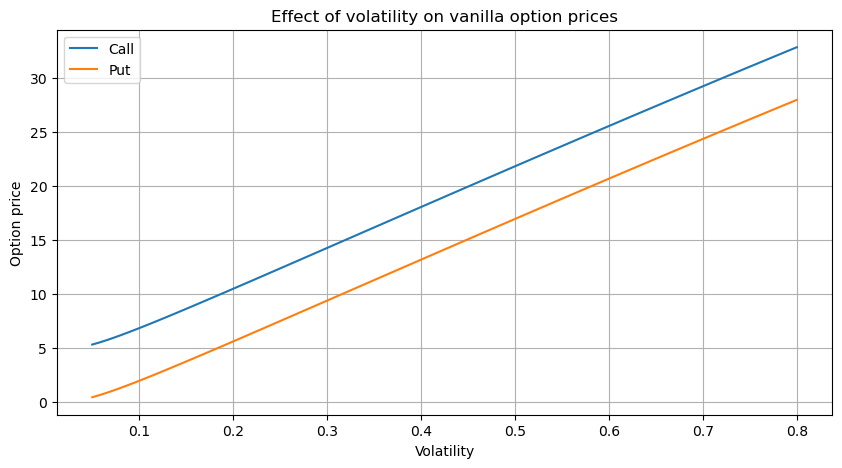

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(vol_sensitivity["volatility"], vol_sensitivity["call_price"], label="Call")
plt.plot(vol_sensitivity["volatility"], vol_sensitivity["put_price"], label="Put")
plt.xlabel("Volatility")
plt.ylabel("Option price")
plt.title("Effect of volatility on vanilla option prices")
plt.legend()
plt.grid(True)
plt.show()

## Rate

In [10]:
rate_grid = np.linspace(0.0, 0.10, 100)

rate_sensitivity = pd.DataFrame(
    {
        "rate": rate_grid,
    }
)

rate_sensitivity["call_price"] = [
    BlackScholesModel(rate=rate, volatility=market_data.volatility).price(
        call,
        MarketData(
            spot=market_data.spot,
            rate=rate,
            volatility=market_data.volatility,
            dividend_yield=market_data.dividend_yield,
        ),
    )
    for rate in rate_grid
]

rate_sensitivity["put_price"] = [
    BlackScholesModel(rate=rate, volatility=market_data.volatility).price(
        put,
        MarketData(
            spot=market_data.spot,
            rate=rate,
            volatility=market_data.volatility,
            dividend_yield=market_data.dividend_yield,
        ),
    )
    for rate in rate_grid
]

rate_sensitivity.head()

,rate,call_price,put_price
0,0.00000,7.965567,7.965567
1,0.00101,8.012127,7.911168
2,0.00202,8.058842,7.857026
3,0.00303,8.105712,7.803141
4,0.00404,8.152737,7.749512


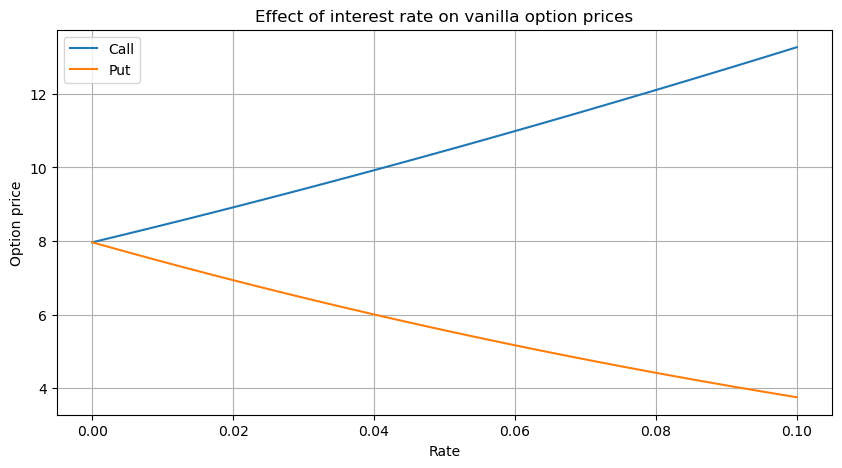

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(rate_sensitivity["rate"], rate_sensitivity["call_price"], label="Call")
plt.plot(rate_sensitivity["rate"], rate_sensitivity["put_price"], label="Put")
plt.xlabel("Rate")
plt.ylabel("Option price")
plt.title("Effect of interest rate on vanilla option prices")
plt.legend()
plt.grid(True)
plt.show()

## Spot impact on delta, gamma, vega

In [12]:
spot_grid = np.linspace(50.0, 150.0, 150)

greeks_by_spot = []

for spot in spot_grid:
    md = MarketData(
        spot=spot,
        rate=0.05,
        volatility=0.20,
        dividend_yield=0.0,
    )
    greeks = bs_model.greeks(call, md)
    greeks_by_spot.append(
        {
            "spot": spot,
            "price": greeks["price"],
            "delta": greeks["delta"],
            "gamma": greeks["gamma"],
            "vega": greeks["vega"],
        }
    )

greeks_by_spot = pd.DataFrame(greeks_by_spot)
greeks_by_spot.head()

,spot,price,delta,gamma,vega
0,50.000000,0.002399,0.000917,0.000311,0.155545
1,50.671141,0.003090,0.001148,0.000377,0.193594
2,51.342282,0.003951,0.001426,0.000454,0.239214
3,52.013423,0.005016,0.001759,0.000542,0.293524
4,52.684564,0.006327,0.002157,0.000644,0.357738


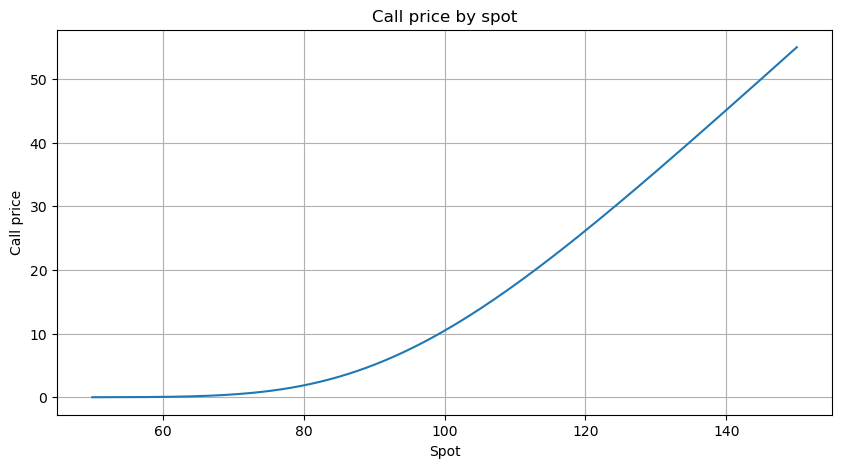

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(greeks_by_spot["spot"], greeks_by_spot["price"])
plt.xlabel("Spot")
plt.ylabel("Call price")
plt.title("Call price by spot")
plt.grid(True)
plt.show()

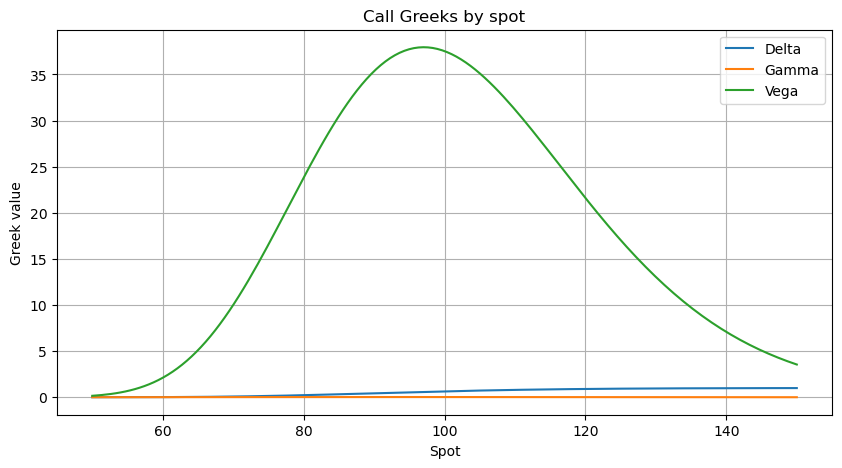

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(greeks_by_spot["spot"], greeks_by_spot["delta"], label="Delta")
plt.plot(greeks_by_spot["spot"], greeks_by_spot["gamma"], label="Gamma")
plt.plot(greeks_by_spot["spot"], greeks_by_spot["vega"], label="Vega")
plt.xlabel("Spot")
plt.ylabel("Greek value")
plt.title("Call Greeks by spot")
plt.legend()
plt.grid(True)
plt.show()